In [1]:
import pandas as pd
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

from data_import import load_guardian_years

In [2]:
DATA_DIR = Path("data/raw/guardian_by_year")

In [3]:
df_all_raw = load_guardian_years(list(range(2005, 2026)), folder=DATA_DIR)

In [4]:
len(df_all_raw)

155551

In [5]:
df_missing_author = df_all_raw.loc[(df_all_raw['n_contributors'] == 0) & ((df_all_raw['author_raw'].isna()) | (df_all_raw['author_raw'] == ""))]
print(f"Number of articles with missing author: {len(df_missing_author)}")
df_missing_author.head()

Number of articles with missing author: 2242


,id,title,summary,date,url,author_raw,contributors,n_contributors,keywords,body_text,section_id,section_name,year
829,commentisfree/2006/apr/07/science.socialcare,These brain electrodes are no miracle cure for...,People with mental health problems need therap...,2006-04-06 23:14:38+00:00,https://www.theguardian.com/commentisfree/2006...,,[],0,"[Science, Social care, Health, Society, Health...",The Guardian gave enthusiastic coverage to new...,commentisfree,Opinion,2006
881,commentisfree/2006/apr/09/leaders.birdflu,We can beat bird flu if Europe helps the world,<b>Leader: </b>A dead swan floats ashore and i...,2006-04-08 23:15:15+00:00,https://www.theguardian.com/commentisfree/2006...,,[],0,"[Bird flu, World news]",A dead swan floats ashore and is found to carr...,commentisfree,Opinion,2006
999,commentisfree/2006/apr/13/politics.publicservices,Meddling judges make it worse,<b>Leader:</b> Judges have rightly ruled thems...,2006-04-12 23:02:32+00:00,https://www.theguardian.com/commentisfree/2006...,,[],0,"[Politics, Health, Society, UK news, Assisted ...",Judges have rightly ruled themselves ineligibl...,commentisfree,Opinion,2006
1215,commentisfree/2006/apr/21/comment.highereducation,Muslim students are not being influenced by ex...,Rows over Hizb ut-Tahrir overshadow the emerge...,2006-04-20 23:03:03+00:00,https://www.theguardian.com/commentisfree/2006...,,[],0,"[Higher education, Race, Religion, Education, ...",A Guardian Education article sought to attribu...,commentisfree,Opinion,2006
1313,commentisfree/2006/apr/25/comment.food,Don't blame McDonald's for society's ills,Please judge us on the facts: our food is nutr...,2006-04-24 23:02:45+00:00,https://www.theguardian.com/commentisfree/2006...,,[],0,"[Advertising, Health, Media, Society, Food, UK...",Many people have strong views on McDonald's. N...,commentisfree,Opinion,2006


In [6]:
df_missing_body_text = df_all_raw.loc[df_all_raw['body_text'].isna() | (df_all_raw['body_text'].str.strip() == "")]
print(f"Number of articles with missing body text: {len(df_missing_body_text)}")
df_missing_body_text.head()

Number of articles with missing body text: 836


,id,title,summary,date,url,author_raw,contributors,n_contributors,keywords,body_text,section_id,section_name,year
28296,commentisfree/michaeltomasky/2008/oct/02/usele...,Tomasky talk: Palin v Biden,<p><strong>Tomasky talk:</strong> As Joe Biden...,2008-10-02 00:00:02+00:00,https://www.theguardian.com/commentisfree/mich...,Michael Tomasky,[Michael Tomasky],1,"[US elections 2008, Joe Biden, Sarah Palin, Re...",,commentisfree,Opinion,2008
37851,commentisfree/libertycentral/2009/jun/15/refug...,'Displacement is not new',<p><strong>Video: Refugee Week 2009: </strong>...,2009-06-15 11:53:32+00:00,https://www.theguardian.com/commentisfree/libe...,Rowan Williams,[Rowan Williams],1,"[Refugees, Immigration and asylum, UK civil li...",,commentisfree,Opinion,2009
50194,commentisfree/2010/oct/22/comic-sans-type-ligh...,Comic Sans not your type? Lighten up,<p><strong>Dan Hancox:</strong> What does it s...,2010-10-22 13:15:43+00:00,https://www.theguardian.com/commentisfree/2010...,Dan Hancox,[Dan Hancox],1,"[Design, Art and design, Culture, World news, ...",,commentisfree,Opinion,2010
50350,commentisfree/belief/2010/oct/27/religion,An interview with Stanley Hauerwas,<p><strong>Video:</strong> Theologian Stanley ...,2010-10-27 13:31:50+00:00,https://www.theguardian.com/commentisfree/beli...,,[],0,"[Religion, World news]",,commentisfree,Opinion,2010
56981,commentisfree/2011/jun/30/are-you-on-strike-to...,Are you on strike today? Tell us why,<p>We asked readers to tell us why they were s...,2011-06-30 09:49:00+00:00,https://www.theguardian.com/commentisfree/2011...,Jessica Reed and Bella Mackie,"[Jessica Reed, Bella Mackie]",2,"[Trade unions, TUC, Public sector cuts, Public...",,commentisfree,Opinion,2011


In [7]:
df_all_raw.loc[df_all_raw['keywords'].isna() | (df_all_raw['keywords'].str.strip() == "")].head()

,id,title,summary,date,url,author_raw,contributors,n_contributors,keywords,body_text,section_id,section_name,year


In [8]:
df_all_raw.loc[df_all_raw['title'].isna() | (df_all_raw['title'].str.strip() == "")].head()

,id,title,summary,date,url,author_raw,contributors,n_contributors,keywords,body_text,section_id,section_name,year


In [9]:
df_missing_summary = df_all_raw.loc[df_all_raw['summary'].isna() | (df_all_raw['summary'].str.strip() == "")]
print(f"Number of articles with missing summary: {len(df_missing_summary)}")
df_missing_summary.head()

Number of articles with missing summary: 55


,id,title,summary,date,url,author_raw,contributors,n_contributors,keywords,body_text,section_id,section_name,year
5,commentisfree/2006/mar/01/whiteteeth,White teeth,,2006-03-01 11:54:37+00:00,https://www.theguardian.com/commentisfree/2006...,Anne Perkins,[Anne Perkins],1,"[David Cameron, Gordon Brown]",David Cameron certainly has them. Gordon Brown...,commentisfree,Opinion,2006
19,commentisfree/2006/mar/09/howtheguardianworks1,How the Guardian works,,2006-03-09 11:49:54+00:00,https://www.theguardian.com/commentisfree/2006...,Murray Armstrong,[Murray Armstrong],1,[],Welcome to the editors' blog. Note where the p...,commentisfree,Opinion,2006
55,commentisfree/2006/mar/14/welcometocommentisfree,Welcome to Comment is free,,2006-03-14 09:22:40+00:00,https://www.theguardian.com/commentisfree/2006...,Georgina Henry,[Georgina Henry],1,[Blogging],"Welcome to Comment is free, the first collecti...",commentisfree,Opinion,2006
60,commentisfree/2006/mar/14/updatetoisraeliaggre...,"Update to Israeli aggression, British Betrayal",,2006-03-14 11:55:08+00:00,https://www.theguardian.com/commentisfree/2006...,George Galloway,[George Galloway],1,"[Jack Straw, World news, Middle East and north...",I sent the following letter to the foreign sec...,commentisfree,Opinion,2006
64,commentisfree/2006/mar/14/deadlybugs,Deadly bugs,,2006-03-14 13:15:59+00:00,https://www.theguardian.com/commentisfree/2006...,Glenn Reynolds,[Glenn Reynolds],1,[],"Avian flu is established in Asia and Africa, a...",commentisfree,Opinion,2006


In [10]:
df_invalid_filtered = df_all_raw.loc[
    ~(((df_all_raw['n_contributors'] == 0) & ((df_all_raw['author_raw'].isna()) | (df_all_raw['author_raw'] == ""))) |
    (df_all_raw['body_text'].isna() | (df_all_raw['body_text'].str.strip() == "")) |
    (df_all_raw['summary'].isna() | (df_all_raw['summary'].str.strip() == "")))
]

print("Number of articles after filtering: ", len(df_invalid_filtered))

Number of articles after filtering:  152423


In [11]:
author_col="contributors"

if author_col not in df_invalid_filtered.columns:
    raise ValueError(f"Column '{author_col}' not found in dataframe.")

author_series = df_invalid_filtered[author_col].copy()

# Make sure each cell is a list
author_series = author_series.apply(
    lambda x: x if isinstance(x, list) else []
)

# One row per (article, contributor)
exploded = df_invalid_filtered[["id", author_col]].copy()
exploded[author_col] = author_series
exploded = exploded.explode(author_col)

# Count unique articles per contributor
authors_article_count = (
    exploded.groupby(author_col)["id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={author_col: "contributor", "id": "n_articles"})
)

In [12]:
authors_article_count.head(10)

,contributor,n_articles
0,Editorial,8111
1,Simon Jenkins,1890
2,Michael Tomasky,1847
3,Polly Toynbee,1735
4,Zoe Williams,1521
5,Martin Kettle,1282
6,Arwa Mahdawi,1265
7,Jonathan Freedland,1148
8,Observer editorial,1099
9,Catherine Bennett,1014


In [13]:
authors_article_count.describe()

,n_articles
count,18988.000000
mean,7.427849
std,74.280097
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,8111.000000


In [84]:
print("Number of authors with 1 articles:", len(authors_article_count[authors_article_count["n_articles"] == 1]))

Number of authors with 1 articles: 11117


In [14]:
print("Number of authors with more than 10 articles:", len(authors_article_count[authors_article_count["n_articles"] > 10]))

Number of authors with more than 10 articles: 1600


In [15]:
print("Number of authors with more than 20 articles:", len(authors_article_count[authors_article_count["n_articles"] > 20]))

Number of authors with more than 20 articles: 885


In [81]:
print("Number of authors with more than 100 articles:", len(authors_article_count[authors_article_count["n_articles"] > 100]))

Number of authors with more than 100 articles: 180


In [17]:
print("Number of authors with more than 20 articles:", len(authors_article_count[authors_article_count["n_articles"] > 1000]))

Number of authors with more than 20 articles: 11


Text(0.5, 0, 'Number of Articles per Contributor')

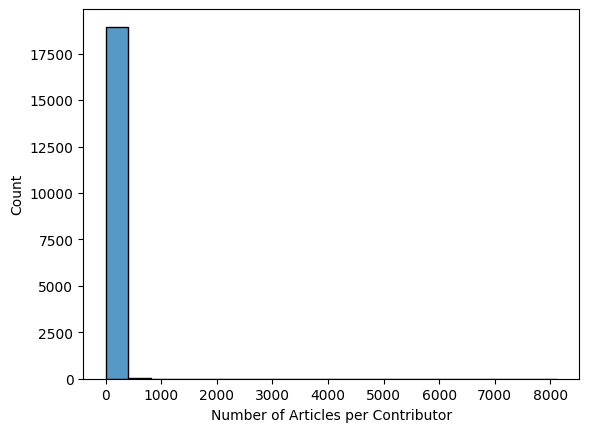

In [82]:
g = sns.histplot(authors_article_count["n_articles"], bins=20);
g.set_xlabel("Number of Articles per Contributor")

In [19]:
df_invalid_filtered["n_contributors"].describe()

count    152423.000000
mean          0.925694
std           0.409778
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          12.000000
Name: n_contributors, dtype: float64

In [59]:
len(df_invalid_filtered.loc[df_invalid_filtered["n_contributors"] == 1])

134568

In [60]:
len(df_invalid_filtered.loc[df_invalid_filtered["n_contributors"] > 0])

137051

In [80]:
print(df_invalid_filtered.sort_values(by=["n_contributors"], ascending=False).iloc[0]['url'])

https://www.theguardian.com/commentisfree/2025/oct/25/black-history-month-panel-the-supremes-marcus-garvey-tupac-shakur-music-museums-film


In [79]:
print(df_invalid_filtered.sort_values(by=["n_contributors"], ascending=False).iloc[1]['url'])

https://www.theguardian.com/commentisfree/2010/oct/20/spending-review-economists-experts-respond


In [64]:
df_invalid_filtered.loc[df_invalid_filtered["n_contributors"] > 0]['n_contributors'].describe()

count    137051.000000
mean          1.029522
std           0.282592
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          12.000000
Name: n_contributors, dtype: float64

Text(0.5, 0, 'Number of Contributors')

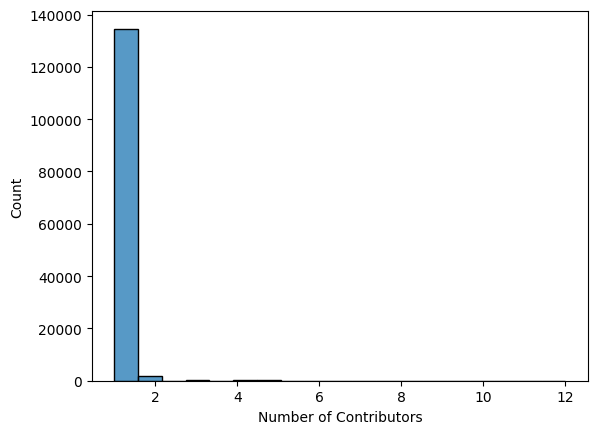

In [68]:
g = sns.histplot(df_invalid_filtered.loc[df_invalid_filtered["n_contributors"] > 0]["n_contributors"]);
g.set_xlabel("Number of Contributors")

In [21]:
year_count = df_invalid_filtered.groupby("year").size().reset_index(name="count")
year_count['year'] = year_count['year'].astype(int)

/var/folders/hp/2tgr4qfj4gz39lyrkptx7w3c0000gn/T/ipykernel_16133/1717346127.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=90);


Text(0, 0.5, 'Number of Articles')

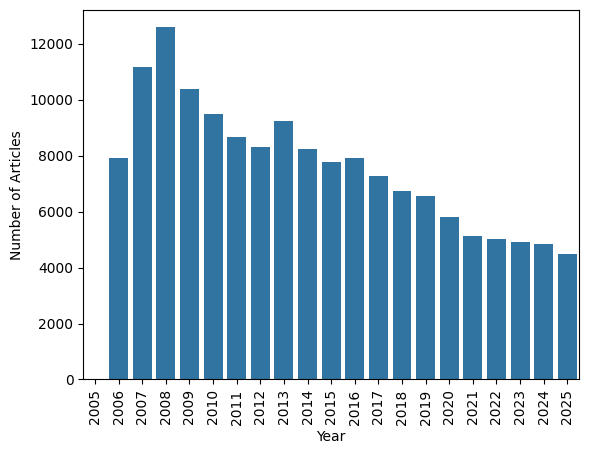

In [83]:
g = sns.barplot(year_count, x="year", y="count")
g.set_xticklabels(g.get_xticklabels(), rotation=90);
g.set_xlabel("Year")
g.set_ylabel("Number of Articles")

In [23]:
df_invalid_filtered['body_text_length'] = df_invalid_filtered['body_text'].str.len()

/var/folders/hp/2tgr4qfj4gz39lyrkptx7w3c0000gn/T/ipykernel_16133/1577450298.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_invalid_filtered['body_text_length'] = df_invalid_filtered['body_text'].str.len()


In [38]:
print("Number of articles with less than 50 characters:", len(df_invalid_filtered.loc[df_invalid_filtered['body_text_length'] < 50]))

Number of articles with less than 50 characters: 7


In [87]:
df_invalid_filtered.loc[df_invalid_filtered['body_text_length'] < 50]

,id,title,summary,date,url,author_raw,contributors,n_contributors,keywords,body_text,section_id,section_name,year,body_text_length
26812,commentisfree/michaeltomasky/2008/aug/25/democ...,Tomasky talk: Backing Biden,<p>Michael Tomasky looks at how Obama's choice...,2008-08-25 09:41:24+00:00,https://www.theguardian.com/commentisfree/mich...,Michael Tomasky,[Michael Tomasky],1,"[US elections 2008, Democratic convention 2008...",Michael Tomasky on Obama's choice of running mate,commentisfree,Opinion,2008,49
31221,commentisfree/2008/dec/11/conservatives-davidc...,At home with the Camerons,<p><strong>Open thread:</strong> What do you t...,2008-12-11 12:00:00+00:00,https://www.theguardian.com/commentisfree/2008...,Open thread,[],0,"[Conservatives, David Cameron, Christmas]",Discuss.,commentisfree,Opinion,2008,8
31410,commentisfree/2008/dec/16/gordon-brown-tony-bl...,Cards on the table,<p><strong>Open thread:</strong> Compare and c...,2008-12-16 10:29:58+00:00,https://www.theguardian.com/commentisfree/2008...,Open thread,[],0,"[Gordon Brown, Tony Blair, Cherie Blair, Chris...",Compare and contrast.,commentisfree,Opinion,2008,21
65722,commentisfree/2012/jul/23/you-tell-us,Ideas for 23-24 July,<p>Post your suggestions for subjects you'd li...,2012-07-23 10:09:00+00:00,https://www.theguardian.com/commentisfree/2012...,Bella Mackie,[Bella Mackie],1,[],1,commentisfree,Opinion,2012,1
85916,commentisfree/2014/sep/24/steve-bell-on-ed-mil...,Steve Bell on Ed Miliband – cartoon,Ed Miliband has been criticised after forgetti...,2014-09-24 22:38:09+00:00,https://www.theguardian.com/commentisfree/2014...,Steve Bell,[Steve Bell],1,"[Ed Miliband, Labour, David Cameron, George Os...",<b></b>,commentisfree,Opinion,2014,7
103625,commentisfree/2016/dec/16/first-dog-on-the-moo...,First Dog on the Moon's do-it-yourself nativit...,Say au revoir to 2016 with this intra-denomina...,2016-12-16 07:01:39+00:00,https://www.theguardian.com/commentisfree/2016...,First Dog on the Moon,[First Dog on the Moon],1,"[Christmas, Australia news, Malcolm Turnbull, ...","For the full, printable PDF click here",commentisfree,Opinion,2016,38
154399,commentisfree/2025/sep/21/my-20s-seven-book-ti...,And then there was one: my 20s in seven book t...,From a Dickensian romance to the mythology of ...,2025-09-21 13:00:44+00:00,https://www.theguardian.com/commentisfree/2025...,Ella Scheuerell,[Ella Scheuerell],1,"[Life and style, Books, Culture]",Ella Scheuerell is an editorial cartoonist,commentisfree,Opinion,2025,42


In [95]:
df_invalid_filtered.loc[65722, 'url']

'https://www.theguardian.com/commentisfree/2012/jul/23/you-tell-us'

In [36]:
print("Number of articles with less than 100 characters:", len(df_invalid_filtered.loc[df_invalid_filtered['body_text_length'] < 100]))

Number of articles with less than 100 characters: 57


In [35]:
df_invalid_filtered.loc[df_invalid_filtered['body_text_length'] < 100, "body_text"]

499       At the National Review Online, Daniel Doron ha...
9932      This article has been removed as the copyright...
10035     This article has been removed as the copyright...
12307     This article has been removed as the copyright...
19590     This article has been removed as the copyright...
20273     Ernest Hemingway sitting at his typewriter. Im...
20983     The editors' blog has moved to the Inside sect...
21897     This article has been removed as the copyright...
25780     This article has been removed as the copyright...
26185     This article has been deleted as our copyright...
26388     This article has been removed as our copyright...
26812     Michael Tomasky on Obama's choice of running mate
26833     Michael Tomasky on tonight's speech by Michell...
26844     This article has been removed as our copyright...
26877     Michael Tomasky on what happens after the came...
26936     Michael Tomasky visits Arianna Huffington's ma...
26959     Michael Tomasky talks about ho

In [98]:
df_invalid_filtered.loc[27544, 'url']

'https://www.theguardian.com/commentisfree/2008/sep/13/uselections2008.republicans'

In [34]:
print("Number of articles with less than 1000 characters:", len(df_invalid_filtered.loc[df_invalid_filtered['body_text_length'] < 1000]))

Number of articles with less than 1000 characters: 3219


In [26]:
df_invalid_filtered['body_text_length'].describe()

count       152423.0
mean     4774.672372
std      1865.435223
min              1.0
25%           3690.0
50%           4672.0
75%           5834.0
max          46067.0
Name: body_text_length, dtype: Float64

Text(0.5, 0, 'Body Text Length (characters)')

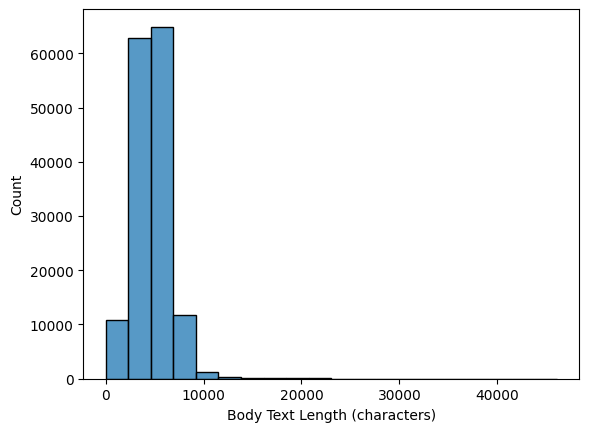

In [85]:
g = sns.histplot(df_invalid_filtered['body_text_length'], bins=20);
g.set_xlabel("Body Text Length (characters)")

Text(0.5, 0, 'Body Text Length (characters) - log scale')

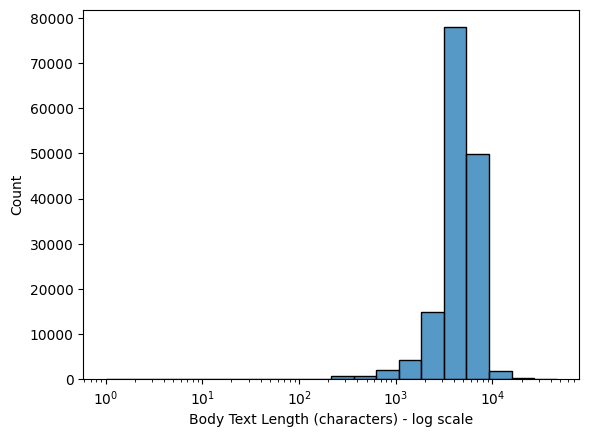

In [86]:
g= sns.histplot(df_invalid_filtered['body_text_length'], bins=20, log_scale=True);
g.set_xlabel("Body Text Length (characters) - log scale")

In [44]:
df_len_filtered = df_invalid_filtered.loc[df_invalid_filtered['body_text_length'] >= 1000]
print("Number of articles with at least 1000 characters:", len(df_len_filtered))

Number of articles with at least 1000 characters: 149204


In [41]:
df_len_filtered['body_text_length'].describe()

count       149204.0
mean     4863.853234
std      1782.359732
min           1000.0
25%           3749.0
50%           4716.0
75%           5865.0
max          46067.0
Name: body_text_length, dtype: Float64

Text(0.5, 0, 'Body Text Length (characters)')

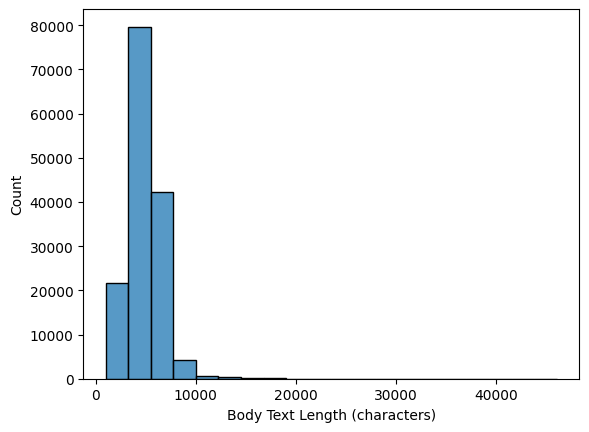

In [100]:
g= sns.histplot(df_len_filtered['body_text_length'], bins=20);
g.set_xlabel("Body Text Length (characters)")

Text(0.5, 0, 'Body Text Length (characters) - log scale')

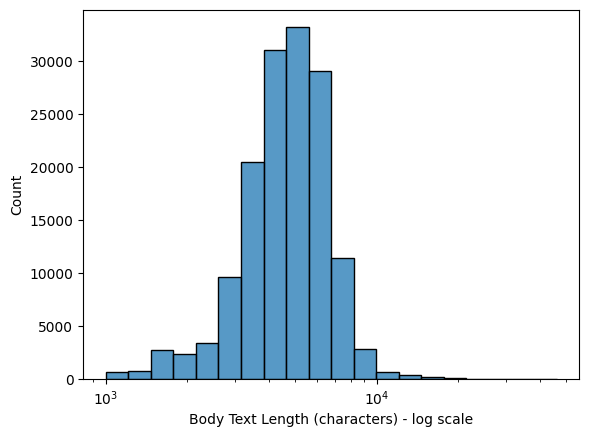

In [99]:
g = sns.histplot(df_len_filtered['body_text_length'], bins=20, log_scale=True);
g.set_xlabel("Body Text Length (characters) - log scale")

In [101]:
df_len_filtered.sort_values('body_text_length', ascending=False).head()

,id,title,summary,date,url,author_raw,contributors,n_contributors,keywords,body_text,section_id,section_name,year,body_text_length
39542,commentisfree/belief/2009/aug/28/religion-chri...,Nicky Gumbel interview transcript,<p><strong>Adam Rutherford: </strong>This is t...,2009-08-28 11:00:02+00:00,https://www.theguardian.com/commentisfree/beli...,Adam Rutherford,[Adam Rutherford],1,"[Religion, Christianity, Atheism, LGBTQ+ right...","Adam Rutherford: Ok, would you mind stating yo...",commentisfree,Opinion,2009,46067
149692,commentisfree/2024/sep/13/israel-palestine-7-o...,‘Many people would throw a tantrum at this poi...,Couples Therapy’s Orna Guralnik and former par...,2024-09-13 10:00:55+00:00,https://www.theguardian.com/commentisfree/2024...,,[Ling Ko],1,"[Israel-Gaza war, Palestine, Israel, Gaza, Ham...",Orna Guralnik and Christine met on the docuser...,commentisfree,Opinion,2024,44880
6517,commentisfree/2006/nov/06/post582,The roads from Suez,<p><strong>Martin Woollacott:</strong> Fifty y...,2006-11-06 15:42:12+00:00,https://www.theguardian.com/commentisfree/2006...,Martin Woollacott,[Martin Woollacott],1,[],The Egyptian coast slid below as the British p...,commentisfree,Opinion,2006,39873
92727,commentisfree/2015/aug/09/oral-history-civil-r...,'Things will never be the same': the oral hist...,"One year ago, the world turned to Ferguson. Fr...",2015-08-09 20:05:10+00:00,https://www.theguardian.com/commentisfree/2015...,Megan Carpentier,[Megan Carpentier],1,"[Protest, US policing, Ferguson, Civil rights ...","Saturday 9 August 2014: ‘Oh my God, they left ...",commentisfree,Opinion,2015,39091
77113,commentisfree/2013/oct/09/the-rise-of-the-read...,The rise of the reader: journalism in the age ...,"Katharine Viner, deputy&nbsp;editor of the Gua...",2013-10-09 07:45:59+00:00,https://www.theguardian.com/commentisfree/2013...,Katharine Viner,[Katharine Viner],1,"[Media, Journalism education, Australia news, ...",I'd like to begin with a true story. I was rec...,commentisfree,Opinion,2013,37901


In [102]:
df_len_filtered.loc[39542, "url"]

'https://www.theguardian.com/commentisfree/belief/2009/aug/28/religion-christianity-alpha-gumbel-transcript'

In [103]:
df_len_filtered.loc[149692, "url"]

'https://www.theguardian.com/commentisfree/2024/sep/13/israel-palestine-7-october-gaza-orna-guralnik'

In [104]:
df_len_filtered.loc[6517, "url"]

'https://www.theguardian.com/commentisfree/2006/nov/06/post582'

In [46]:
df_len_filtered.to_parquet("data/processed/guardian_articles_filtered.parquet")

In [47]:
df_len_filtered = pd.read_parquet("data/processed/guardian_articles_filtered.parquet")

In [115]:
df_len_filtered_sample = df_len_filtered.sample(n=2500, random_state=4300)
df_len_filtered_sample.to_csv("data/processed/guardian_articles_sample.csv", index=False)
df_len_filtered_sample.to_parquet("data/processed/guardian_articles_sample.parquet", index=False)